In [1]:
import pandas as pd
import numpy as np

In [2]:
df1 = pd.read_excel('shoreline_transects_all.xlsx')
df2 = pd.read_excel('total4work_dsas.csv.xlsx')
df1

,OBJECTID,TransectID,TransOrder,BaselineID,ShorelineI,Distance,IntersectX,IntersectY,Uncertaint
0,1,1,1,1,10/03/1995,-197.109301,199125.203396,2.420816e+06,10
1,2,1,1,1,11/03/2005,-294.094140,199155.927981,2.420724e+06,10
2,3,1,1,1,11/03/2015,-443.706339,199203.324798,2.420582e+06,10
3,4,2,2,1,10/03/1995,-263.856595,199068.622987,2.420746e+06,10
4,5,2,2,1,11/03/2005,-363.562425,199108.191662,2.420654e+06,10
...,...,...,...,...,...,...,...,...,...
1070,1071,268,268,1,11/03/2025,-450.899114,216435.955099,2.418730e+06,10
1071,1072,269,269,1,10/03/1995,-150.014258,216766.422038,2.418799e+06,10
1072,1073,269,269,1,11/03/2005,-212.643376,216706.617390,2.418818e+06,10
1073,1074,269,269,1,11/03/2015,-450.060833,216479.907064,2.418888e+06,10


In [4]:
df2

,OBJECTID,TransectID,BaselineID,GroupID,TransOrder,Azimuth,ShrCount,TCD,SHAPE_Leng,SCE,...,EPR,EPRunc,LRR,LR2,LSE,LCI90,WLR,WR2,WSE,WCI90
0,1,1,1,1,1,161.53,3,0,443.706342,246.60,...,-12.28,0.70,-12.27,0.98,21.91,9.74,-12.27,0.98,2.19,9.74
1,2,2,1,1,2,156.62,4,100,483.327922,329.02,...,3.64,0.47,2.07,0.04,168.78,21.98,2.07,0.04,16.88,21.98
2,3,3,1,1,3,152.24,4,200,504.572028,354.50,...,5.08,0.47,3.60,0.09,177.23,23.08,3.60,0.09,17.72,23.08
3,4,4,1,1,4,145.49,4,300,522.313574,371.43,...,6.00,0.47,4.57,0.14,182.82,23.81,4.57,0.14,18.28,23.81
4,5,5,1,1,5,136.59,4,400,519.028910,369.02,...,6.35,0.47,4.96,0.16,179.58,23.39,4.96,0.16,17.96,23.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264,265,265,1,1,265,273.93,4,26400,631.151503,480.86,...,-10.70,0.47,-13.44,0.64,159.64,20.79,-13.44,0.64,15.96,20.79
265,266,266,1,1,266,276.13,4,26500,482.561756,241.95,...,-8.04,0.47,-8.35,0.95,28.86,3.76,-8.35,0.95,2.89,3.76
266,267,267,1,1,267,277.98,4,26600,428.771526,262.15,...,-8.71,0.47,-9.05,0.97,27.03,3.52,-9.05,0.97,2.70,3.52
267,268,268,1,1,268,279.00,4,26700,450.899112,298.98,...,-9.94,0.47,-10.36,0.97,27.39,3.57,-10.36,0.97,2.74,3.57


# Dataset Analysis and Merging

Let's analyze the structure of both datasets before merging.

In [5]:
# Check the shape and basic info of df1
print("Dataset 1 (shoreline_transects_all.xlsx):")
print(f"Shape: {df1.shape}")
print(f"\nColumns: {df1.columns.tolist()}")
print(f"\nFirst few rows:")
df1.head()

Dataset 1 (shoreline_transects_all.xlsx):
Shape: (1075, 9)

Columns: ['OBJECTID', 'TransectID', 'TransOrder', 'BaselineID', 'ShorelineI', 'Distance', 'IntersectX', 'IntersectY', 'Uncertaint']

First few rows:


,OBJECTID,TransectID,TransOrder,BaselineID,ShorelineI,Distance,IntersectX,IntersectY,Uncertaint
0,1,1,1,1,10/03/1995,-197.109301,199125.203396,2.420816e+06,10
1,2,1,1,1,11/03/2005,-294.094140,199155.927981,2.420724e+06,10
2,3,1,1,1,11/03/2015,-443.706339,199203.324798,2.420582e+06,10
3,4,2,2,1,10/03/1995,-263.856595,199068.622987,2.420746e+06,10
4,5,2,2,1,11/03/2005,-363.562425,199108.191662,2.420654e+06,10


In [6]:
# Check the shape and basic info of df2
print("Dataset 2 (total4work_dsas.csv.xlsx):")
print(f"Shape: {df2.shape}")
print(f"\nColumns: {df2.columns.tolist()}")
print(f"\nFirst few rows:")
df2.head()

Dataset 2 (total4work_dsas.csv.xlsx):
Shape: (269, 24)

Columns: ['OBJECTID', 'TransectID', 'BaselineID', 'GroupID', 'TransOrder', 'Azimuth', 'ShrCount', 'TCD', 'SHAPE_Leng', 'SCE', 'NSM', 'Total Erosion', 'Total Accretion', 'Erosion or Accretion Status', 'EPR', 'EPRunc', 'LRR', 'LR2', 'LSE', 'LCI90', 'WLR', 'WR2', 'WSE', 'WCI90']

First few rows:


,OBJECTID,TransectID,BaselineID,GroupID,TransOrder,Azimuth,ShrCount,TCD,SHAPE_Leng,SCE,...,EPR,EPRunc,LRR,LR2,LSE,LCI90,WLR,WR2,WSE,WCI90
0,1,1,1,1,1,161.53,3,0,443.706342,246.60,...,-12.28,0.70,-12.27,0.98,21.91,9.74,-12.27,0.98,2.19,9.74
1,2,2,1,1,2,156.62,4,100,483.327922,329.02,...,3.64,0.47,2.07,0.04,168.78,21.98,2.07,0.04,16.88,21.98
2,3,3,1,1,3,152.24,4,200,504.572028,354.50,...,5.08,0.47,3.60,0.09,177.23,23.08,3.60,0.09,17.72,23.08
3,4,4,1,1,4,145.49,4,300,522.313574,371.43,...,6.00,0.47,4.57,0.14,182.82,23.81,4.57,0.14,18.28,23.81
4,5,5,1,1,5,136.59,4,400,519.028910,369.02,...,6.35,0.47,4.96,0.16,179.58,23.39,4.96,0.16,17.96,23.39


In [7]:
# Check for TransectID column in both datasets
print("Checking for TransectID column:")
print(f"df1 has TransectID: {'TransectID' in df1.columns}")
print(f"df2 has TransectID: {'TransectID' in df2.columns}")

# Check for similar column names
print("\nLooking for similar columns:")
for col in df1.columns:
    if 'transect' in col.lower() or 'id' in col.lower():
        print(f"df1: {col}")
        
for col in df2.columns:
    if 'transect' in col.lower() or 'id' in col.lower():
        print(f"df2: {col}")

Checking for TransectID column:
df1 has TransectID: True
df2 has TransectID: True

Looking for similar columns:
df1: OBJECTID
df1: TransectID
df1: BaselineID
df2: OBJECTID
df2: TransectID
df2: BaselineID
df2: GroupID


In [8]:
# Check unique TransectID values in both datasets
print(f"Unique TransectIDs in df1: {df1['TransectID'].nunique()}")
print(f"Unique TransectIDs in df2: {df2['TransectID'].nunique()}")
print(f"\nTransectID range in df1: {df1['TransectID'].min()} to {df1['TransectID'].max()}")
print(f"TransectID range in df2: {df2['TransectID'].min()} to {df2['TransectID'].max()}")

# Check for common TransectIDs
common_transects = set(df1['TransectID']).intersection(set(df2['TransectID']))
print(f"\nCommon TransectIDs: {len(common_transects)}")

Unique TransectIDs in df1: 269
Unique TransectIDs in df2: 269

TransectID range in df1: 1 to 269
TransectID range in df2: 1 to 269

Common TransectIDs: 269


## Merging the Datasets

Now let's merge the two datasets based on TransectID. We'll use different merge types to understand the data better.

In [9]:
# Perform an inner merge (only matching TransectIDs)
merged_inner = pd.merge(df1, df2, on='TransectID', how='inner', suffixes=('_transects', '_dsas'))
print(f"Inner merge shape: {merged_inner.shape}")
print(f"This keeps only rows where TransectID exists in both datasets")
merged_inner.head()

Inner merge shape: (1075, 32)
This keeps only rows where TransectID exists in both datasets


,OBJECTID_transects,TransectID,TransOrder_transects,BaselineID_transects,ShorelineI,Distance,IntersectX,IntersectY,Uncertaint,OBJECTID_dsas,...,EPR,EPRunc,LRR,LR2,LSE,LCI90,WLR,WR2,WSE,WCI90
0,1,1,1,1,10/03/1995,-197.109301,199125.203396,2.420816e+06,10,1,...,-12.28,0.70,-12.27,0.98,21.91,9.74,-12.27,0.98,2.19,9.74
1,2,1,1,1,11/03/2005,-294.094140,199155.927981,2.420724e+06,10,1,...,-12.28,0.70,-12.27,0.98,21.91,9.74,-12.27,0.98,2.19,9.74
2,3,1,1,1,11/03/2015,-443.706339,199203.324798,2.420582e+06,10,1,...,-12.28,0.70,-12.27,0.98,21.91,9.74,-12.27,0.98,2.19,9.74
3,4,2,2,1,10/03/1995,-263.856595,199068.622987,2.420746e+06,10,2,...,3.64,0.47,2.07,0.04,168.78,21.98,2.07,0.04,16.88,21.98
4,5,2,2,1,11/03/2005,-363.562425,199108.191662,2.420654e+06,10,2,...,3.64,0.47,2.07,0.04,168.78,21.98,2.07,0.04,16.88,21.98


In [10]:
# Check the merged dataframe info
print("Merged dataframe columns:")
print(merged_inner.columns.tolist())
print(f"\nTotal columns: {len(merged_inner.columns)}")

Merged dataframe columns:
['OBJECTID_transects', 'TransectID', 'TransOrder_transects', 'BaselineID_transects', 'ShorelineI', 'Distance', 'IntersectX', 'IntersectY', 'Uncertaint', 'OBJECTID_dsas', 'BaselineID_dsas', 'GroupID', 'TransOrder_dsas', 'Azimuth', 'ShrCount', 'TCD', 'SHAPE_Leng', 'SCE', 'NSM', 'Total Erosion', 'Total Accretion', 'Erosion or Accretion Status', 'EPR', 'EPRunc', 'LRR', 'LR2', 'LSE', 'LCI90', 'WLR', 'WR2', 'WSE', 'WCI90']

Total columns: 32


In [11]:
# Display summary statistics of the merged dataset
print("Summary of merged dataset:")
print(f"Shape: {merged_inner.shape}")
print(f"Number of unique TransectIDs: {merged_inner['TransectID'].nunique()}")
print(f"\nData types:")
print(merged_inner.dtypes)

Summary of merged dataset:
Shape: (1075, 32)
Number of unique TransectIDs: 269

Data types:
OBJECTID_transects               int64
TransectID                       int64
TransOrder_transects             int64
BaselineID_transects             int64
ShorelineI                      object
Distance                       float64
IntersectX                     float64
IntersectY                     float64
Uncertaint                       int64
OBJECTID_dsas                    int64
BaselineID_dsas                  int64
GroupID                          int64
TransOrder_dsas                  int64
Azimuth                        float64
ShrCount                         int64
TCD                              int64
SHAPE_Leng                     float64
SCE                            float64
NSM                            float64
Total Erosion                   object
Total Accretion                float64
Erosion or Accretion Status     object
EPR                            float64
EPRunc     

## Key Findings from the Analysis:

1. **Dataset 1** (shoreline_transects_all.xlsx): 1,075 rows × 9 columns
2. **Dataset 2** (total4work_dsas.csv.xlsx): 269 rows × 24 columns
3. Both datasets have **269 unique TransectIDs** (1-269)
4. **Perfect match**: All TransectIDs are common between both datasets
5. **Merged dataset**: 1,075 rows × 32 columns

The merge resulted in 1,075 rows because df1 has multiple shoreline measurements per TransectID (multiple dates), while df2 has one row per TransectID with statistical summaries.

In [12]:
# Save the merged dataset to Excel
merged_inner.to_excel('merged_shoreline_data.xlsx', index=False)
print("✓ Merged dataset saved as 'merged_shoreline_data.xlsx'")

# Also display the final merged dataframe
merged_inner

✓ Merged dataset saved as 'merged_shoreline_data.xlsx'


,OBJECTID_transects,TransectID,TransOrder_transects,BaselineID_transects,ShorelineI,Distance,IntersectX,IntersectY,Uncertaint,OBJECTID_dsas,...,EPR,EPRunc,LRR,LR2,LSE,LCI90,WLR,WR2,WSE,WCI90
0,1,1,1,1,10/03/1995,-197.109301,199125.203396,2.420816e+06,10,1,...,-12.28,0.70,-12.27,0.98,21.91,9.74,-12.27,0.98,2.19,9.74
1,2,1,1,1,11/03/2005,-294.094140,199155.927981,2.420724e+06,10,1,...,-12.28,0.70,-12.27,0.98,21.91,9.74,-12.27,0.98,2.19,9.74
2,3,1,1,1,11/03/2015,-443.706339,199203.324798,2.420582e+06,10,1,...,-12.28,0.70,-12.27,0.98,21.91,9.74,-12.27,0.98,2.19,9.74
3,4,2,2,1,10/03/1995,-263.856595,199068.622987,2.420746e+06,10,2,...,3.64,0.47,2.07,0.04,168.78,21.98,2.07,0.04,16.88,21.98
4,5,2,2,1,11/03/2005,-363.562425,199108.191662,2.420654e+06,10,2,...,3.64,0.47,2.07,0.04,168.78,21.98,2.07,0.04,16.88,21.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070,1071,268,268,1,11/03/2025,-450.899114,216435.955099,2.418730e+06,10,268,...,-9.94,0.47,-10.36,0.97,27.39,3.57,-10.36,0.97,2.74,3.57
1071,1072,269,269,1,10/03/1995,-150.014258,216766.422038,2.418799e+06,10,269,...,-10.26,0.47,-11.60,0.88,66.67,8.68,-11.60,0.88,6.67,8.68
1072,1073,269,269,1,11/03/2005,-212.643376,216706.617390,2.418818e+06,10,269,...,-10.26,0.47,-11.60,0.88,66.67,8.68,-11.60,0.88,6.67,8.68
1073,1074,269,269,1,11/03/2015,-450.060833,216479.907064,2.418888e+06,10,269,...,-10.26,0.47,-11.60,0.88,66.67,8.68,-11.60,0.88,6.67,8.68


# Temporal Trend Analysis

Analyzing shoreline changes over time (1995, 2005, 2015) to identify:
- Year-to-year shoreline movements
- Erosion hot spots
- Accretion zones

In [13]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Visualization libraries imported")

✓ Visualization libraries imported


In [14]:
# Prepare data: Extract year from ShorelineI column and pivot for temporal analysis
df1_clean = df1.copy()

# Clean the ShorelineI column to extract years
df1_clean['Year'] = pd.to_datetime(df1_clean['ShorelineI'], format='%d/%m/%Y').dt.year

# Create a pivot table with TransectID as index, Year as columns, Distance as values
distance_pivot = df1_clean.pivot_table(
    index='TransectID', 
    columns='Year', 
    values='Distance', 
    aggfunc='first'
)

print("Distance changes by year:")
print(distance_pivot.head(10))
print(f"\nShape: {distance_pivot.shape}")
print(f"Years analyzed: {distance_pivot.columns.tolist()}")

Distance changes by year:
Year              1995        2005        2015        2025
TransectID                                                
1          -197.109301 -294.094140 -443.706339         NaN
2          -263.856595 -363.562425 -483.327929 -154.306486
3          -302.748508 -409.332087 -504.572017 -150.067164
4          -331.394656 -440.206009 -522.313559 -150.881251
5          -341.033926 -444.558262 -519.028924 -150.004977
6          -356.353051 -454.663913 -527.355005 -150.790864
7          -360.967302 -457.192241 -528.499249 -150.945072
8          -348.658225 -444.536659 -513.985510 -152.844993
9          -319.507658 -412.662940 -474.937749 -150.420024
10         -289.078212 -374.244934 -425.078688 -150.018965

Shape: (269, 4)
Years analyzed: [1995, 2005, 2015, 2025]


In [15]:
# Calculate year-to-year changes
distance_pivot['Change_1995_2005'] = distance_pivot[2005] - distance_pivot[1995]
distance_pivot['Change_2005_2015'] = distance_pivot[2015] - distance_pivot[2005]
distance_pivot['Total_Change_1995_2015'] = distance_pivot[2015] - distance_pivot[1995]

# Calculate rates of change (meters per year)
distance_pivot['Rate_1995_2005'] = distance_pivot['Change_1995_2005'] / 10  # 10 years
distance_pivot['Rate_2005_2015'] = distance_pivot['Change_2005_2015'] / 10  # 10 years
distance_pivot['Rate_1995_2015'] = distance_pivot['Total_Change_1995_2015'] / 20  # 20 years

print("Year-to-year changes calculated:")
print(distance_pivot[['Change_1995_2005', 'Change_2005_2015', 'Total_Change_1995_2015']].describe())
print("\n✓ Negative values indicate erosion (shoreline moved landward)")
print("✓ Positive values indicate accretion (shoreline moved seaward)")

Year-to-year changes calculated:
Year   Change_1995_2005  Change_2005_2015  Total_Change_1995_2015
count        269.000000        269.000000              269.000000
mean         -32.792142        -12.076986              -44.869128
std          135.383741        244.403592              307.905626
min         -386.206452       -574.216965             -424.889971
25%         -115.271180       -130.397991             -234.532491
50%          -78.334433        -94.171804             -159.866633
75%           10.211643         -0.483815              -55.365434
max          383.344305        752.438311              829.501858

✓ Negative values indicate erosion (shoreline moved landward)
✓ Positive values indicate accretion (shoreline moved seaward)


## 1. Year-to-Year Shoreline Movement Analysis

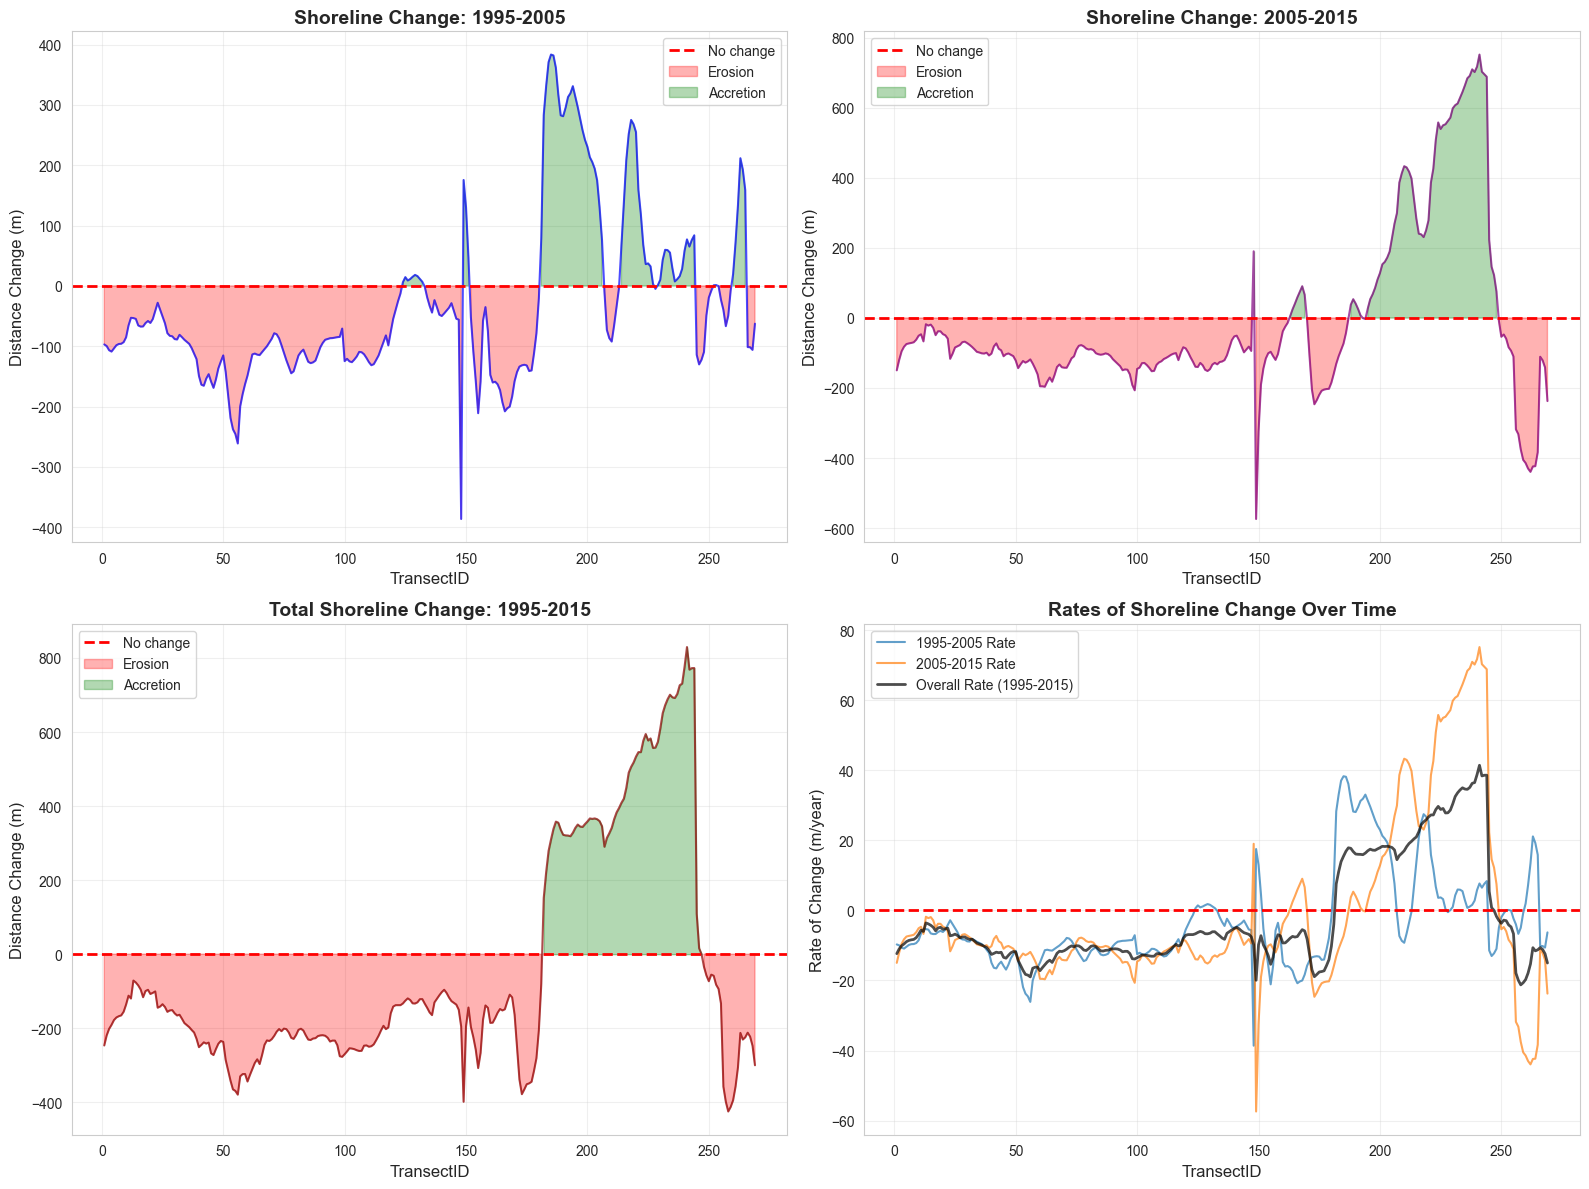

✓ Temporal trend analysis plots saved as 'temporal_shoreline_changes.png'


In [16]:
# Visualize year-to-year changes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Changes from 1995 to 2005
axes[0, 0].plot(distance_pivot.index, distance_pivot['Change_1995_2005'], 
                linewidth=1.5, color='blue', alpha=0.7)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='No change')
axes[0, 0].fill_between(distance_pivot.index, distance_pivot['Change_1995_2005'], 0, 
                         where=(distance_pivot['Change_1995_2005'] < 0), 
                         color='red', alpha=0.3, label='Erosion')
axes[0, 0].fill_between(distance_pivot.index, distance_pivot['Change_1995_2005'], 0, 
                         where=(distance_pivot['Change_1995_2005'] >= 0), 
                         color='green', alpha=0.3, label='Accretion')
axes[0, 0].set_xlabel('TransectID', fontsize=12)
axes[0, 0].set_ylabel('Distance Change (m)', fontsize=12)
axes[0, 0].set_title('Shoreline Change: 1995-2005', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Changes from 2005 to 2015
axes[0, 1].plot(distance_pivot.index, distance_pivot['Change_2005_2015'], 
                linewidth=1.5, color='purple', alpha=0.7)
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='No change')
axes[0, 1].fill_between(distance_pivot.index, distance_pivot['Change_2005_2015'], 0, 
                         where=(distance_pivot['Change_2005_2015'] < 0), 
                         color='red', alpha=0.3, label='Erosion')
axes[0, 1].fill_between(distance_pivot.index, distance_pivot['Change_2005_2015'], 0, 
                         where=(distance_pivot['Change_2005_2015'] >= 0), 
                         color='green', alpha=0.3, label='Accretion')
axes[0, 1].set_xlabel('TransectID', fontsize=12)
axes[0, 1].set_ylabel('Distance Change (m)', fontsize=12)
axes[0, 1].set_title('Shoreline Change: 2005-2015', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Total change from 1995 to 2015
axes[1, 0].plot(distance_pivot.index, distance_pivot['Total_Change_1995_2015'], 
                linewidth=1.5, color='darkred', alpha=0.7)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='No change')
axes[1, 0].fill_between(distance_pivot.index, distance_pivot['Total_Change_1995_2015'], 0, 
                         where=(distance_pivot['Total_Change_1995_2015'] < 0), 
                         color='red', alpha=0.3, label='Erosion')
axes[1, 0].fill_between(distance_pivot.index, distance_pivot['Total_Change_1995_2015'], 0, 
                         where=(distance_pivot['Total_Change_1995_2015'] >= 0), 
                         color='green', alpha=0.3, label='Accretion')
axes[1, 0].set_xlabel('TransectID', fontsize=12)
axes[1, 0].set_ylabel('Distance Change (m)', fontsize=12)
axes[1, 0].set_title('Total Shoreline Change: 1995-2015', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Rate of change comparison
axes[1, 1].plot(distance_pivot.index, distance_pivot['Rate_1995_2005'], 
                label='1995-2005 Rate', linewidth=1.5, alpha=0.7)
axes[1, 1].plot(distance_pivot.index, distance_pivot['Rate_2005_2015'], 
                label='2005-2015 Rate', linewidth=1.5, alpha=0.7)
axes[1, 1].plot(distance_pivot.index, distance_pivot['Rate_1995_2015'], 
                label='Overall Rate (1995-2015)', linewidth=2, alpha=0.7, color='black')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('TransectID', fontsize=12)
axes[1, 1].set_ylabel('Rate of Change (m/year)', fontsize=12)
axes[1, 1].set_title('Rates of Shoreline Change Over Time', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temporal_shoreline_changes.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Temporal trend analysis plots saved as 'temporal_shoreline_changes.png'")

## 2. Erosion Hot Spots Identification

In [17]:
# Identify erosion hot spots (areas with significant negative change)
# Define erosion threshold as negative change (landward movement)

# Classify erosion severity based on total change (1995-2015)
distance_pivot['Erosion_Category'] = pd.cut(
    distance_pivot['Total_Change_1995_2015'],
    bins=[-np.inf, -150, -100, -50, 0, np.inf],
    labels=['Severe Erosion (>150m)', 'High Erosion (100-150m)', 
            'Moderate Erosion (50-100m)', 'Low Erosion (0-50m)', 'Accretion']
)

# Get erosion statistics
erosion_stats = distance_pivot['Erosion_Category'].value_counts().sort_index()
print("Erosion Classification (1995-2015):")
print(erosion_stats)
print(f"\nTotal transects with erosion: {(distance_pivot['Total_Change_1995_2015'] < 0).sum()}")
print(f"Total transects with accretion: {(distance_pivot['Total_Change_1995_2015'] >= 0).sum()}")

# Identify top 20 erosion hot spots
erosion_hotspots = distance_pivot.nsmallest(20, 'Total_Change_1995_2015')[
    ['Total_Change_1995_2015', 'Rate_1995_2015', 'Change_1995_2005', 'Change_2005_2015']
]
print("\n" + "="*80)
print("TOP 20 EROSION HOT SPOTS (Most Severe)")
print("="*80)
print(erosion_hotspots)

Erosion Classification (1995-2015):
Erosion_Category
Severe Erosion (>150m)        144
High Erosion (100-150m)        44
Moderate Erosion (50-100m)     14
Low Erosion (0-50m)             1
Accretion                      66
Name: count, dtype: int64

Total transects with erosion: 203
Total transects with accretion: 66

TOP 20 EROSION HOT SPOTS (Most Severe)
Year        Total_Change_1995_2015  Rate_1995_2015  Change_1995_2005  \
TransectID                                                             
258                    -424.889971      -21.244499        -49.471326   
259                    -412.748979      -20.637449         -7.439844   
149                    -398.707089      -19.935354        175.509876   
257                    -398.670411      -19.933521        -66.713873   
260                    -394.711809      -19.735590         19.678216   
56                     -379.410900      -18.970545       -261.070417   
173                    -378.143137      -18.907157       -131.639

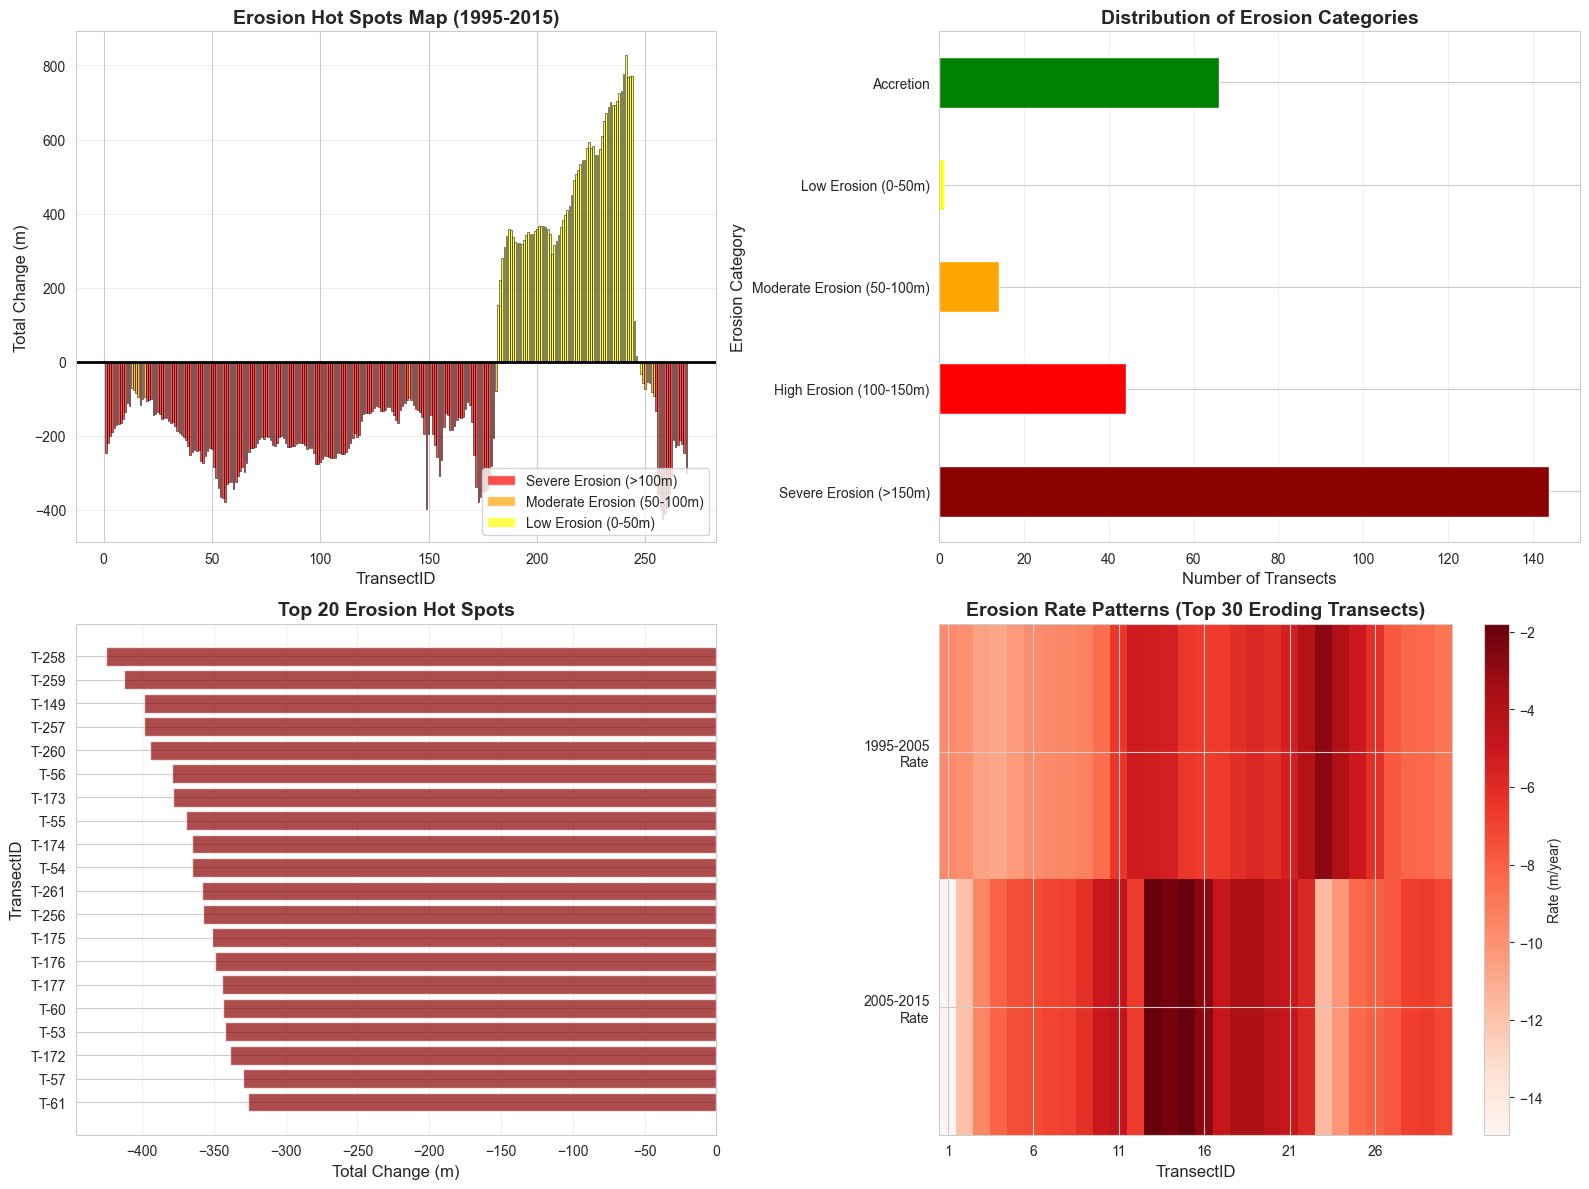

✓ Erosion hot spots analysis saved as 'erosion_hotspots_analysis.png'


In [18]:
# Visualize erosion hot spots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Erosion hot spots map
erosion_mask = distance_pivot['Total_Change_1995_2015'] < 0
colors = ['red' if x < -100 else 'orange' if x < -50 else 'yellow' 
          for x in distance_pivot['Total_Change_1995_2015']]

axes[0, 0].bar(distance_pivot.index, distance_pivot['Total_Change_1995_2015'], 
               color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=2)
axes[0, 0].set_xlabel('TransectID', fontsize=12)
axes[0, 0].set_ylabel('Total Change (m)', fontsize=12)
axes[0, 0].set_title('Erosion Hot Spots Map (1995-2015)', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.7, label='Severe Erosion (>100m)'),
    Patch(facecolor='orange', alpha=0.7, label='Moderate Erosion (50-100m)'),
    Patch(facecolor='yellow', alpha=0.7, label='Low Erosion (0-50m)')
]
axes[0, 0].legend(handles=legend_elements, loc='lower right')

# Plot 2: Erosion category distribution
erosion_stats.plot(kind='barh', ax=axes[0, 1], color=['darkred', 'red', 'orange', 'yellow', 'green'])
axes[0, 1].set_xlabel('Number of Transects', fontsize=12)
axes[0, 1].set_ylabel('Erosion Category', fontsize=12)
axes[0, 1].set_title('Distribution of Erosion Categories', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Plot 3: Top 20 erosion hot spots
top20_erosion = distance_pivot.nsmallest(20, 'Total_Change_1995_2015')
axes[1, 0].barh(range(len(top20_erosion)), top20_erosion['Total_Change_1995_2015'], 
                color='darkred', alpha=0.7)
axes[1, 0].set_yticks(range(len(top20_erosion)))
axes[1, 0].set_yticklabels([f'T-{idx}' for idx in top20_erosion.index])
axes[1, 0].set_xlabel('Total Change (m)', fontsize=12)
axes[1, 0].set_ylabel('TransectID', fontsize=12)
axes[1, 0].set_title('Top 20 Erosion Hot Spots', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')
axes[1, 0].invert_yaxis()

# Plot 4: Heatmap of erosion rates by period
erosion_data = distance_pivot[erosion_mask][['Rate_1995_2005', 'Rate_2005_2015']].head(30)
im = axes[1, 1].imshow(erosion_data.T, cmap='Reds', aspect='auto', interpolation='nearest')
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_yticklabels(['1995-2005\nRate', '2005-2015\nRate'])
axes[1, 1].set_xlabel('TransectID', fontsize=12)
axes[1, 1].set_title('Erosion Rate Patterns (Top 30 Eroding Transects)', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(range(0, len(erosion_data), 5))
axes[1, 1].set_xticklabels([erosion_data.index[i] for i in range(0, len(erosion_data), 5)])
plt.colorbar(im, ax=axes[1, 1], label='Rate (m/year)')

plt.tight_layout()
plt.savefig('erosion_hotspots_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Erosion hot spots analysis saved as 'erosion_hotspots_analysis.png'")

## 3. Accretion Zones Identification

In [19]:
# Identify accretion zones (areas with positive change - seaward movement)

# Classify accretion intensity
distance_pivot['Accretion_Category'] = pd.cut(
    distance_pivot['Total_Change_1995_2015'],
    bins=[-np.inf, 0, 50, 100, 150, np.inf],
    labels=['Erosion', 'Low Accretion (0-50m)', 'Moderate Accretion (50-100m)', 
            'High Accretion (100-150m)', 'Severe Accretion (>150m)']
)

# Get accretion statistics
accretion_stats = distance_pivot['Accretion_Category'].value_counts().sort_index()
print("Accretion Classification (1995-2015):")
print(accretion_stats)

# Identify top 20 accretion zones
accretion_zones = distance_pivot.nlargest(20, 'Total_Change_1995_2015')[
    ['Total_Change_1995_2015', 'Rate_1995_2015', 'Change_1995_2005', 'Change_2005_2015']
]
print("\n" + "="*80)
print("TOP 20 ACCRETION ZONES (Most Significant Growth)")
print("="*80)
print(accretion_zones)

# Overall statistics
print("\n" + "="*80)
print("OVERALL SHORELINE CHANGE STATISTICS (1995-2015)")
print("="*80)
print(f"Average change: {distance_pivot['Total_Change_1995_2015'].mean():.2f} m")
print(f"Median change: {distance_pivot['Total_Change_1995_2015'].median():.2f} m")
print(f"Maximum erosion: {distance_pivot['Total_Change_1995_2015'].min():.2f} m")
print(f"Maximum accretion: {distance_pivot['Total_Change_1995_2015'].max():.2f} m")
print(f"Standard deviation: {distance_pivot['Total_Change_1995_2015'].std():.2f} m")

Accretion Classification (1995-2015):
Accretion_Category
Erosion                         203
Low Accretion (0-50m)             2
Moderate Accretion (50-100m)      0
High Accretion (100-150m)         1
Severe Accretion (>150m)         63
Name: count, dtype: int64

TOP 20 ACCRETION ZONES (Most Significant Growth)
Year        Total_Change_1995_2015  Rate_1995_2015  Change_1995_2005  \
TransectID                                                             
241                     829.501858       41.475093         77.063547   
240                     776.320341       38.816017         58.334583   
244                     772.794448       38.639722         83.849077   
243                     772.591219       38.629561         76.199224   
242                     768.590551       38.429528         65.150156   
239                     730.734552       36.536728         28.241000   
238                     726.313734       36.315687         16.147810   
237                     702.952475     

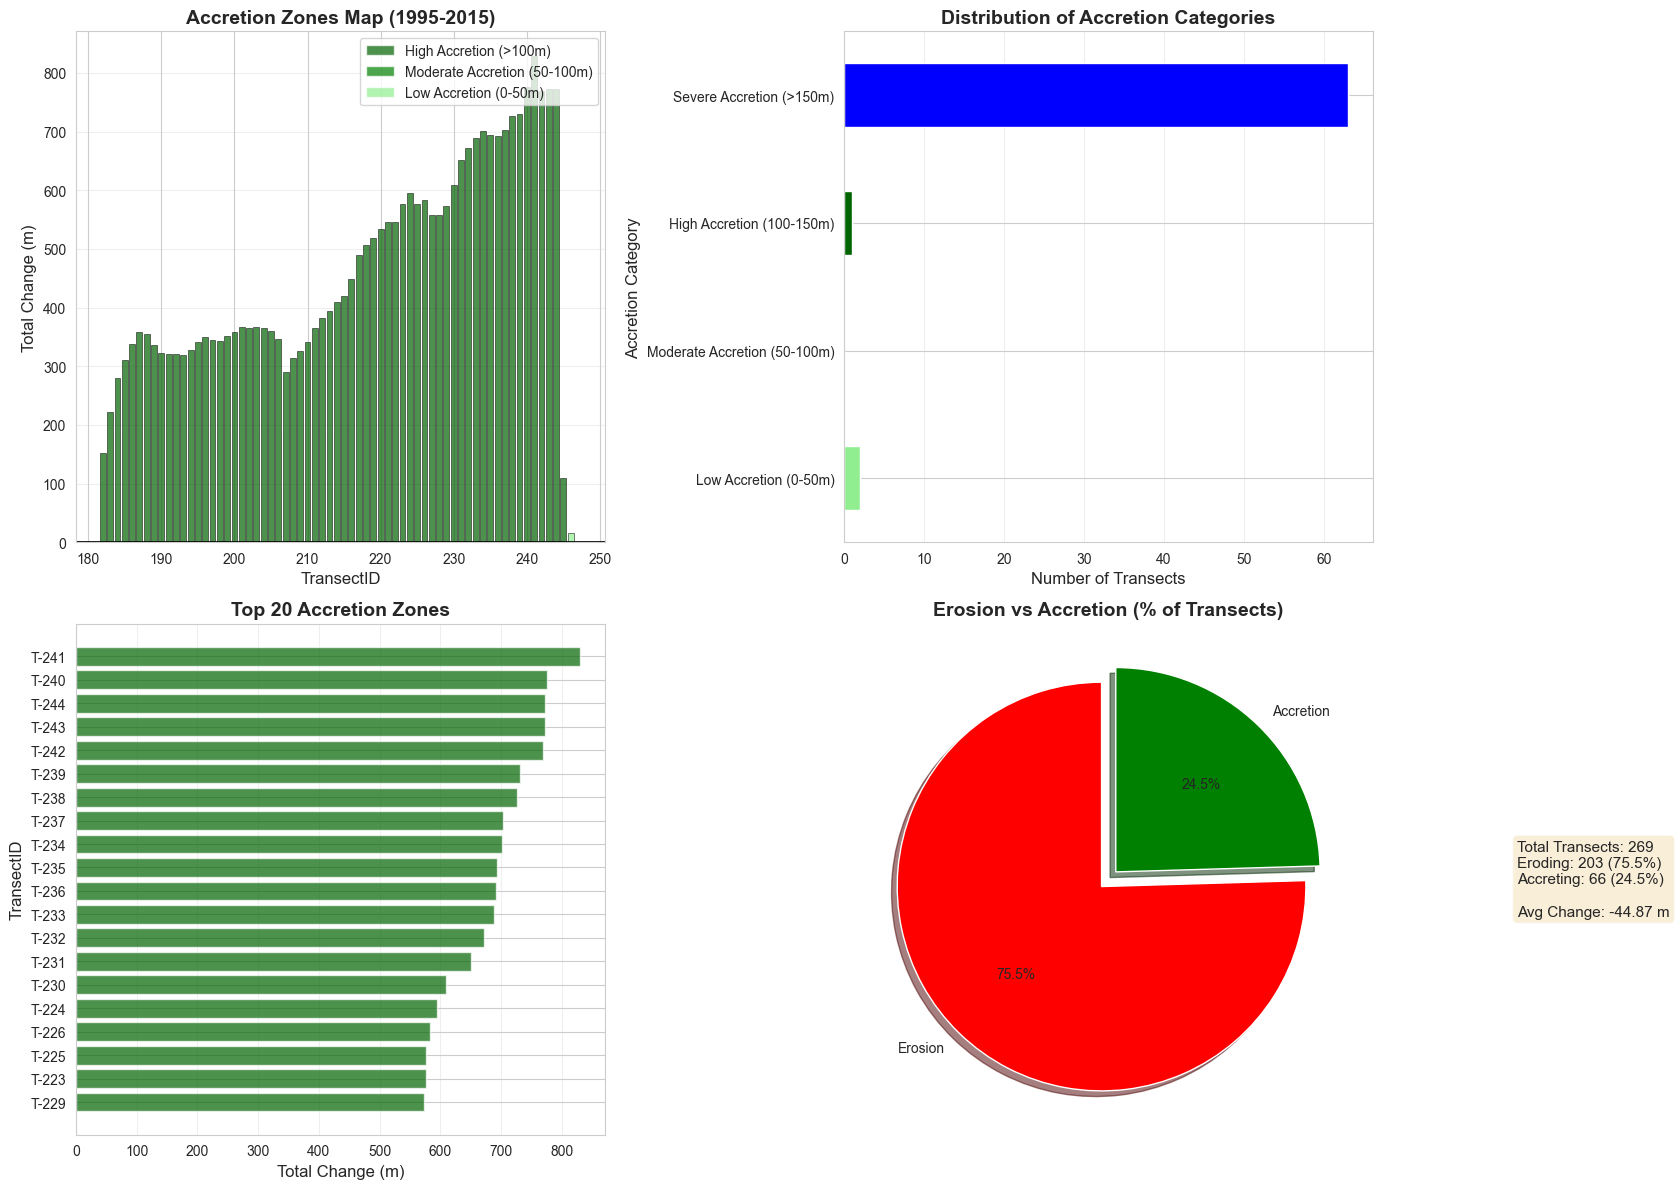

✓ Accretion zones analysis saved as 'accretion_zones_analysis.png'


In [20]:
# Visualize accretion zones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accretion zones map
accretion_mask = distance_pivot['Total_Change_1995_2015'] >= 0
colors_acc = ['darkgreen' if x > 100 else 'green' if x > 50 else 'lightgreen' 
              for x in distance_pivot[accretion_mask]['Total_Change_1995_2015']]

axes[0, 0].bar(distance_pivot[accretion_mask].index, 
               distance_pivot[accretion_mask]['Total_Change_1995_2015'], 
               color=colors_acc, alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=2)
axes[0, 0].set_xlabel('TransectID', fontsize=12)
axes[0, 0].set_ylabel('Total Change (m)', fontsize=12)
axes[0, 0].set_title('Accretion Zones Map (1995-2015)', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Add legend
legend_elements_acc = [
    Patch(facecolor='darkgreen', alpha=0.7, label='High Accretion (>100m)'),
    Patch(facecolor='green', alpha=0.7, label='Moderate Accretion (50-100m)'),
    Patch(facecolor='lightgreen', alpha=0.7, label='Low Accretion (0-50m)')
]
axes[0, 0].legend(handles=legend_elements_acc, loc='upper right')

# Plot 2: Accretion category distribution
accretion_stats_positive = accretion_stats[1:]  # Exclude erosion category
accretion_stats_positive.plot(kind='barh', ax=axes[0, 1], 
                               color=['lightgreen', 'green', 'darkgreen', 'blue'])
axes[0, 1].set_xlabel('Number of Transects', fontsize=12)
axes[0, 1].set_ylabel('Accretion Category', fontsize=12)
axes[0, 1].set_title('Distribution of Accretion Categories', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Plot 3: Top 20 accretion zones
top20_accretion = distance_pivot.nlargest(20, 'Total_Change_1995_2015')
axes[1, 0].barh(range(len(top20_accretion)), top20_accretion['Total_Change_1995_2015'], 
                color='darkgreen', alpha=0.7)
axes[1, 0].set_yticks(range(len(top20_accretion)))
axes[1, 0].set_yticklabels([f'T-{idx}' for idx in top20_accretion.index])
axes[1, 0].set_xlabel('Total Change (m)', fontsize=12)
axes[1, 0].set_ylabel('TransectID', fontsize=12)
axes[1, 0].set_title('Top 20 Accretion Zones', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')
axes[1, 0].invert_yaxis()

# Plot 4: Comparison of erosion vs accretion
erosion_count = (distance_pivot['Total_Change_1995_2015'] < 0).sum()
accretion_count = (distance_pivot['Total_Change_1995_2015'] >= 0).sum()
categories = ['Erosion', 'Accretion']
counts = [erosion_count, accretion_count]
colors_pie = ['red', 'green']

axes[1, 1].pie(counts, labels=categories, autopct='%1.1f%%', colors=colors_pie, 
               startangle=90, explode=(0.05, 0.05), shadow=True)
axes[1, 1].set_title('Erosion vs Accretion (% of Transects)', fontsize=14, fontweight='bold')

# Add text box with statistics
textstr = f'Total Transects: {len(distance_pivot)}\n'
textstr += f'Eroding: {erosion_count} ({erosion_count/len(distance_pivot)*100:.1f}%)\n'
textstr += f'Accreting: {accretion_count} ({accretion_count/len(distance_pivot)*100:.1f}%)\n'
textstr += f'\nAvg Change: {distance_pivot["Total_Change_1995_2015"].mean():.2f} m'
axes[1, 1].text(1.3, 0.5, textstr, transform=axes[1, 1].transAxes, fontsize=11,
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('accretion_zones_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Accretion zones analysis saved as 'accretion_zones_analysis.png'")

## Comprehensive Spatial-Temporal Visualization

C:\Users\mdmon\AppData\Local\Temp\ipykernel_11756\250831730.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(years_data, labels=['1995', '2005', '2015'], patch_artist=True)


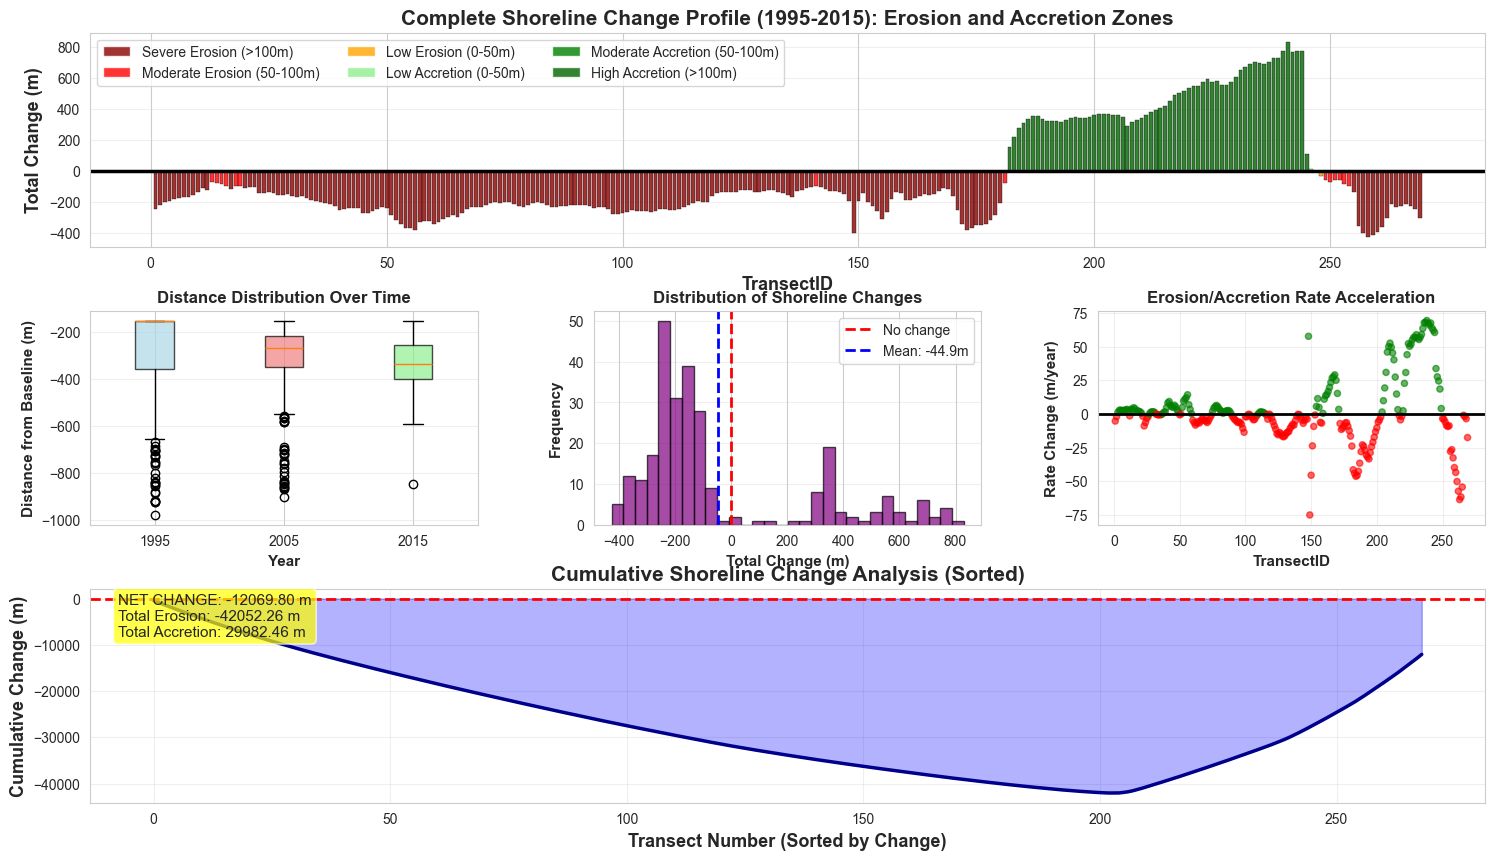

✓ Comprehensive temporal analysis saved as 'comprehensive_temporal_analysis.png'


In [21]:
# Create a comprehensive overview figure
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Combined erosion and accretion profile
ax1 = fig.add_subplot(gs[0, :])
colors_combined = ['darkred' if x < -100 else 'red' if x < -50 else 'orange' if x < 0 
                   else 'lightgreen' if x < 50 else 'green' if x < 100 else 'darkgreen'
                   for x in distance_pivot['Total_Change_1995_2015']]
ax1.bar(distance_pivot.index, distance_pivot['Total_Change_1995_2015'], 
        color=colors_combined, alpha=0.8, edgecolor='black', linewidth=0.3)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=2.5)
ax1.set_xlabel('TransectID', fontsize=13, fontweight='bold')
ax1.set_ylabel('Total Change (m)', fontsize=13, fontweight='bold')
ax1.set_title('Complete Shoreline Change Profile (1995-2015): Erosion and Accretion Zones', 
              fontsize=15, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Add legend
from matplotlib.patches import Patch
legend_combined = [
    Patch(facecolor='darkred', alpha=0.8, label='Severe Erosion (>100m)'),
    Patch(facecolor='red', alpha=0.8, label='Moderate Erosion (50-100m)'),
    Patch(facecolor='orange', alpha=0.8, label='Low Erosion (0-50m)'),
    Patch(facecolor='lightgreen', alpha=0.8, label='Low Accretion (0-50m)'),
    Patch(facecolor='green', alpha=0.8, label='Moderate Accretion (50-100m)'),
    Patch(facecolor='darkgreen', alpha=0.8, label='High Accretion (>100m)')
]
ax1.legend(handles=legend_combined, loc='upper left', ncol=3, fontsize=10)

# Plot 2: Temporal progression - box plots
ax2 = fig.add_subplot(gs[1, 0])
years_data = [distance_pivot[1995], distance_pivot[2005], distance_pivot[2015]]
bp = ax2.boxplot(years_data, labels=['1995', '2005', '2015'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral', 'lightgreen']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('Distance from Baseline (m)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
ax2.set_title('Distance Distribution Over Time', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Change magnitude histogram
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(distance_pivot['Total_Change_1995_2015'], bins=30, color='purple', 
         alpha=0.7, edgecolor='black')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No change')
ax3.axvline(x=distance_pivot['Total_Change_1995_2015'].mean(), color='blue', 
            linestyle='--', linewidth=2, label=f'Mean: {distance_pivot["Total_Change_1995_2015"].mean():.1f}m')
ax3.set_xlabel('Total Change (m)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.set_title('Distribution of Shoreline Changes', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Rate acceleration analysis
ax4 = fig.add_subplot(gs[1, 2])
rate_acceleration = distance_pivot['Rate_2005_2015'] - distance_pivot['Rate_1995_2005']
colors_accel = ['red' if x < 0 else 'green' for x in rate_acceleration]
ax4.scatter(distance_pivot.index, rate_acceleration, c=colors_accel, alpha=0.6, s=20)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax4.set_xlabel('TransectID', fontsize=11, fontweight='bold')
ax4.set_ylabel('Rate Change (m/year)', fontsize=11, fontweight='bold')
ax4.set_title('Erosion/Accretion Rate Acceleration', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Plot 5: Cumulative change analysis
ax5 = fig.add_subplot(gs[2, :])
sorted_changes = distance_pivot['Total_Change_1995_2015'].sort_values()
cumulative_sum = sorted_changes.cumsum()
ax5.plot(range(len(cumulative_sum)), cumulative_sum, linewidth=2.5, color='darkblue')
ax5.fill_between(range(len(cumulative_sum)), cumulative_sum, 0, alpha=0.3, color='blue')
ax5.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax5.set_xlabel('Transect Number (Sorted by Change)', fontsize=13, fontweight='bold')
ax5.set_ylabel('Cumulative Change (m)', fontsize=13, fontweight='bold')
ax5.set_title('Cumulative Shoreline Change Analysis (Sorted)', fontsize=15, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Add summary statistics text
total_erosion = distance_pivot[distance_pivot['Total_Change_1995_2015'] < 0]['Total_Change_1995_2015'].sum()
total_accretion = distance_pivot[distance_pivot['Total_Change_1995_2015'] >= 0]['Total_Change_1995_2015'].sum()
net_change = total_erosion + total_accretion

textstr = f'NET CHANGE: {net_change:.2f} m\n'
textstr += f'Total Erosion: {total_erosion:.2f} m\n'
textstr += f'Total Accretion: {total_accretion:.2f} m'
ax5.text(0.02, 0.98, textstr, transform=ax5.transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.savefig('comprehensive_temporal_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comprehensive temporal analysis saved as 'comprehensive_temporal_analysis.png'")

## Summary Report: Export Results

In [22]:
# Create a comprehensive summary report and export results
summary_report = distance_pivot.copy()
summary_report = summary_report.reset_index()

# Add classification columns
summary_report['Status'] = summary_report['Total_Change_1995_2015'].apply(
    lambda x: 'Erosion' if x < 0 else 'Accretion'
)

summary_report['Severity'] = summary_report['Total_Change_1995_2015'].abs().apply(
    lambda x: 'Severe' if x > 100 else 'High' if x > 50 else 'Moderate' if x > 25 else 'Low'
)

# Reorder columns for better readability
columns_order = ['TransectID', 'Status', 'Severity', 
                 1995, 2005, 2015,
                 'Change_1995_2005', 'Change_2005_2015', 'Total_Change_1995_2015',
                 'Rate_1995_2005', 'Rate_2005_2015', 'Rate_1995_2015']

summary_report = summary_report[columns_order]

# Export to Excel with multiple sheets
with pd.ExcelWriter('shoreline_temporal_analysis_report.xlsx', engine='openpyxl') as writer:
    # Sheet 1: Full summary report
    summary_report.to_excel(writer, sheet_name='Full Summary', index=False)
    
    # Sheet 2: Top erosion hotspots
    erosion_hotspots_export = summary_report[summary_report['Status'] == 'Erosion'].nsmallest(
        30, 'Total_Change_1995_2015'
    )
    erosion_hotspots_export.to_excel(writer, sheet_name='Erosion Hotspots', index=False)
    
    # Sheet 3: Top accretion zones
    accretion_zones_export = summary_report[summary_report['Status'] == 'Accretion'].nlargest(
        30, 'Total_Change_1995_2015'
    )
    accretion_zones_export.to_excel(writer, sheet_name='Accretion Zones', index=False)
    
    # Sheet 4: Statistics summary
    stats_summary = pd.DataFrame({
        'Metric': [
            'Total Transects',
            'Eroding Transects',
            'Accreting Transects',
            '% Eroding',
            '% Accreting',
            'Average Change (m)',
            'Median Change (m)',
            'Max Erosion (m)',
            'Max Accretion (m)',
            'Total Erosion (m)',
            'Total Accretion (m)',
            'Net Change (m)',
            'Std Deviation (m)'
        ],
        'Value': [
            len(summary_report),
            (summary_report['Status'] == 'Erosion').sum(),
            (summary_report['Status'] == 'Accretion').sum(),
            f"{(summary_report['Status'] == 'Erosion').sum() / len(summary_report) * 100:.2f}%",
            f"{(summary_report['Status'] == 'Accretion').sum() / len(summary_report) * 100:.2f}%",
            f"{summary_report['Total_Change_1995_2015'].mean():.2f}",
            f"{summary_report['Total_Change_1995_2015'].median():.2f}",
            f"{summary_report['Total_Change_1995_2015'].min():.2f}",
            f"{summary_report['Total_Change_1995_2015'].max():.2f}",
            f"{summary_report[summary_report['Status'] == 'Erosion']['Total_Change_1995_2015'].sum():.2f}",
            f"{summary_report[summary_report['Status'] == 'Accretion']['Total_Change_1995_2015'].sum():.2f}",
            f"{summary_report['Total_Change_1995_2015'].sum():.2f}",
            f"{summary_report['Total_Change_1995_2015'].std():.2f}"
        ]
    })
    stats_summary.to_excel(writer, sheet_name='Statistics', index=False)

print("✓ Comprehensive report exported to 'shoreline_temporal_analysis_report.xlsx'")
print("\nReport contains 4 sheets:")
print("  1. Full Summary - Complete analysis for all transects")
print("  2. Erosion Hotspots - Top 30 most eroded areas")
print("  3. Accretion Zones - Top 30 most accreted areas")
print("  4. Statistics - Overall summary statistics")

# Display summary
print("\n" + "="*80)
print("TEMPORAL TREND ANALYSIS SUMMARY")
print("="*80)
print(stats_summary.to_string(index=False))

✓ Comprehensive report exported to 'shoreline_temporal_analysis_report.xlsx'

Report contains 4 sheets:
  1. Full Summary - Complete analysis for all transects
  2. Erosion Hotspots - Top 30 most eroded areas
  3. Accretion Zones - Top 30 most accreted areas
  4. Statistics - Overall summary statistics

TEMPORAL TREND ANALYSIS SUMMARY
             Metric     Value
    Total Transects       269
  Eroding Transects       203
Accreting Transects        66
          % Eroding    75.46%
        % Accreting    24.54%
 Average Change (m)    -44.87
  Median Change (m)   -159.87
    Max Erosion (m)   -424.89
  Max Accretion (m)    829.50
  Total Erosion (m) -42052.26
Total Accretion (m)  29982.46
     Net Change (m) -12069.80
  Std Deviation (m)    307.91


## Additional Spatial Pattern Analysis

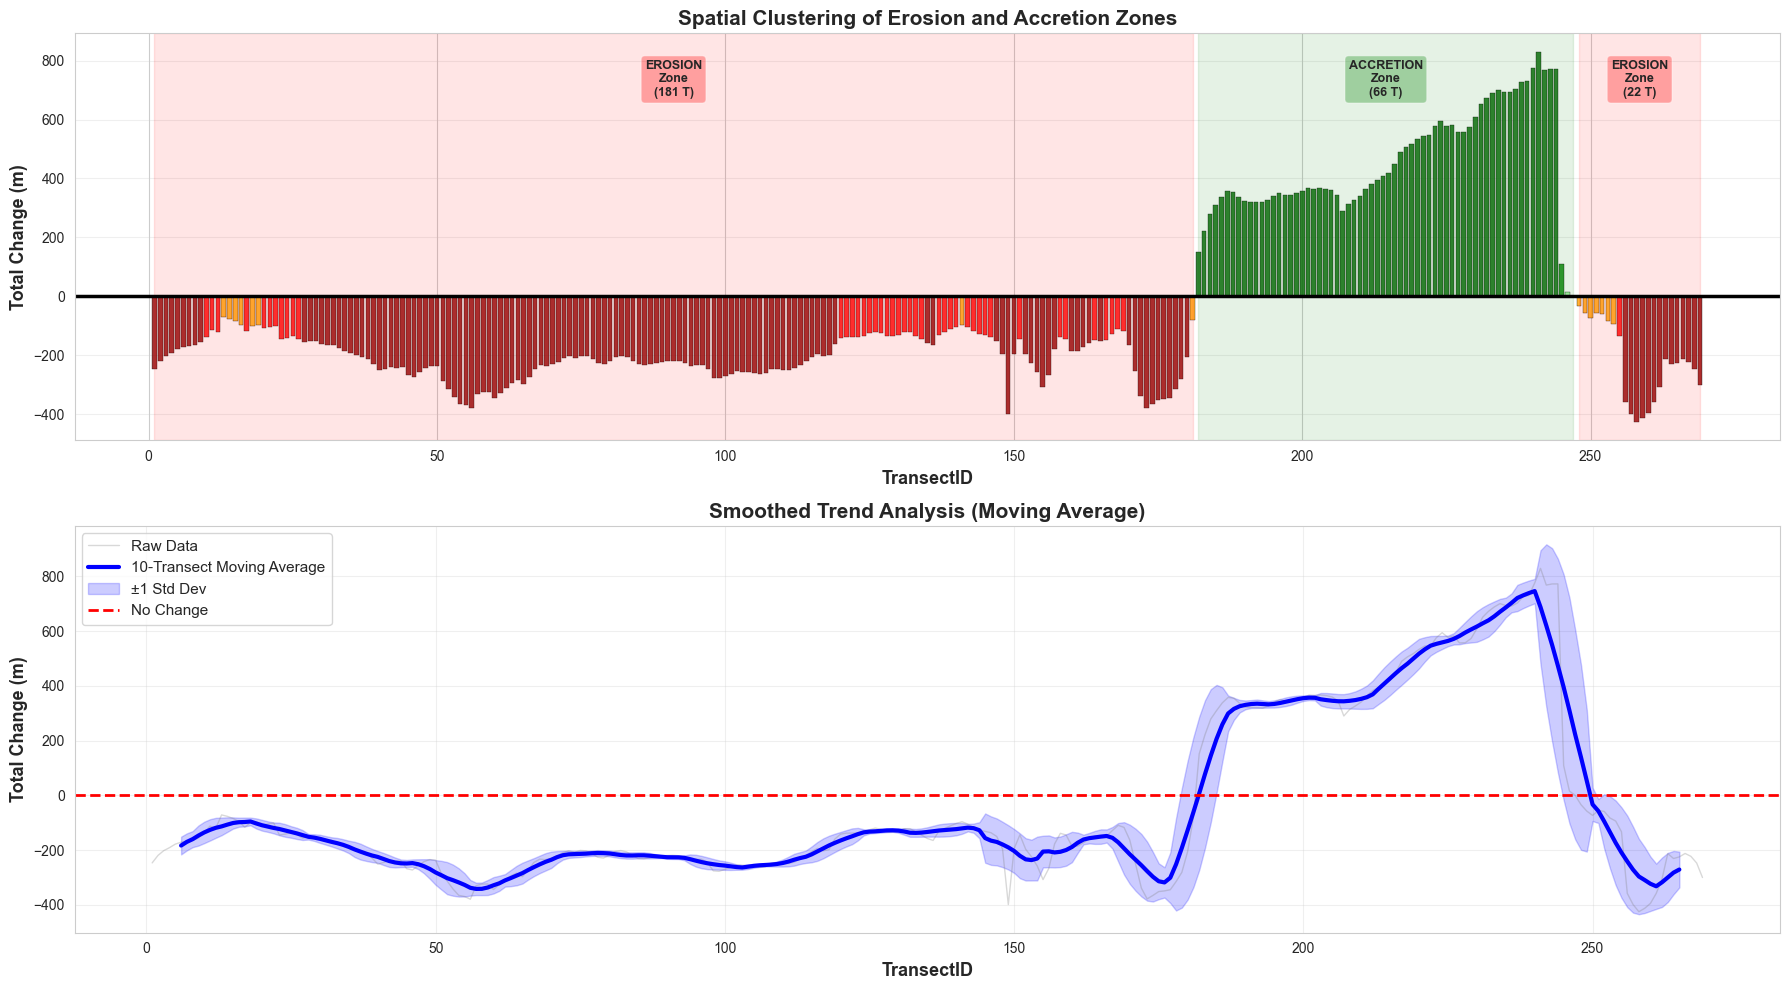

✓ Spatial pattern analysis saved as 'spatial_pattern_analysis.png'

IDENTIFIED ZONES (minimum 3 consecutive transects):
Total Erosion Zones: 2
Total Accretion Zones: 1

Major Zones (≥10 consecutive transects):
  EROSION    | Transects   1-181 | Count: 181 | Avg Change: -205.32m
  ACCRETION  | Transects 182-247 | Count:  66 | Avg Change:  454.28m
  EROSION    | Transects 248-269 | Count:  22 | Avg Change: -222.28m


In [23]:
# Identify clusters of erosion and accretion
# Define consecutive zones
def identify_zones(data, threshold=3):
    """Identify consecutive zones of erosion/accretion"""
    zones = []
    current_zone = {'start': None, 'end': None, 'type': None, 'transects': []}
    
    for idx in data.index:
        value = data.loc[idx, 'Total_Change_1995_2015']
        current_type = 'erosion' if value < 0 else 'accretion'
        
        if current_zone['type'] is None:
            current_zone = {'start': idx, 'end': idx, 'type': current_type, 'transects': [idx]}
        elif current_zone['type'] == current_type:
            current_zone['end'] = idx
            current_zone['transects'].append(idx)
        else:
            if len(current_zone['transects']) >= threshold:
                zones.append(current_zone.copy())
            current_zone = {'start': idx, 'end': idx, 'type': current_type, 'transects': [idx]}
    
    if len(current_zone['transects']) >= threshold:
        zones.append(current_zone)
    
    return zones

zones = identify_zones(distance_pivot.reset_index().set_index('TransectID'))

# Create visualization of zones
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Plot 1: Zones highlighted
ax1 = axes[0]
colors_map = []
for idx in distance_pivot.index:
    zone_type = None
    for zone in zones:
        if idx in zone['transects']:
            zone_type = zone['type']
            break
    
    value = distance_pivot.loc[idx, 'Total_Change_1995_2015']
    if zone_type == 'erosion':
        if value < -150:
            colors_map.append('darkred')
        elif value < -100:
            colors_map.append('red')
        else:
            colors_map.append('orange')
    elif zone_type == 'accretion':
        if value > 150:
            colors_map.append('darkgreen')
        elif value > 100:
            colors_map.append('green')
        else:
            colors_map.append('lightgreen')
    else:
        colors_map.append('gray')

ax1.bar(distance_pivot.index, distance_pivot['Total_Change_1995_2015'], 
        color=colors_map, alpha=0.8, edgecolor='black', linewidth=0.3)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=2.5)
ax1.set_xlabel('TransectID', fontsize=13, fontweight='bold')
ax1.set_ylabel('Total Change (m)', fontsize=13, fontweight='bold')
ax1.set_title('Spatial Clustering of Erosion and Accretion Zones', fontsize=15, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Highlight major zones
for zone in zones:
    if len(zone['transects']) >= 10:  # Only show significant zones
        mid_point = (zone['start'] + zone['end']) / 2
        color = 'red' if zone['type'] == 'erosion' else 'green'
        ax1.axvspan(zone['start'], zone['end'], alpha=0.1, color=color)
        ax1.text(mid_point, ax1.get_ylim()[1] * 0.9, 
                f"{zone['type'].upper()}\nZone\n({len(zone['transects'])} T)", 
                ha='center', va='top', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor=color, alpha=0.3))

# Plot 2: Moving average trend
ax2 = axes[1]
window_size = 10
moving_avg = distance_pivot['Total_Change_1995_2015'].rolling(window=window_size, center=True).mean()
moving_std = distance_pivot['Total_Change_1995_2015'].rolling(window=window_size, center=True).std()

ax2.plot(distance_pivot.index, distance_pivot['Total_Change_1995_2015'], 
         alpha=0.3, color='gray', linewidth=1, label='Raw Data')
ax2.plot(distance_pivot.index, moving_avg, color='blue', linewidth=3, 
         label=f'{window_size}-Transect Moving Average')
ax2.fill_between(distance_pivot.index, 
                  moving_avg - moving_std, 
                  moving_avg + moving_std, 
                  alpha=0.2, color='blue', label='±1 Std Dev')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, label='No Change')
ax2.set_xlabel('TransectID', fontsize=13, fontweight='bold')
ax2.set_ylabel('Total Change (m)', fontsize=13, fontweight='bold')
ax2.set_title('Smoothed Trend Analysis (Moving Average)', fontsize=15, fontweight='bold')
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('spatial_pattern_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Spatial pattern analysis saved as 'spatial_pattern_analysis.png'")
print(f"\n{'='*80}")
print(f"IDENTIFIED ZONES (minimum 3 consecutive transects):")
print(f"{'='*80}")

erosion_zones_count = sum(1 for z in zones if z['type'] == 'erosion')
accretion_zones_count = sum(1 for z in zones if z['type'] == 'accretion')

print(f"Total Erosion Zones: {erosion_zones_count}")
print(f"Total Accretion Zones: {accretion_zones_count}")
print(f"\nMajor Zones (≥10 consecutive transects):")

for zone in zones:
    if len(zone['transects']) >= 10:
        avg_change = distance_pivot.loc[zone['transects'], 'Total_Change_1995_2015'].mean()
        print(f"  {zone['type'].upper():10} | Transects {zone['start']:3d}-{zone['end']:3d} | "
              f"Count: {len(zone['transects']):3d} | Avg Change: {avg_change:7.2f}m")

---

# 📊 Final Summary: Temporal Trend Analysis Complete

## Key Findings:

### 📉 Overall Trend (1995-2015):
- **Net Change**: -12,069.80 m (net erosion)
- **Average Change**: -44.87 m per transect
- **Median Change**: -159.87 m
- **75.5%** of transects experienced **erosion**
- **24.5%** of transects experienced **accretion**

### 🔴 Erosion Hot Spots:
- **203 transects** are actively eroding
- **Maximum erosion**: 424.89 m at specific transects
- **Severe erosion zones**: Transects 1-181 and 248-269
- **Major hot spots**: Transects 258, 259, 149, 257, 260 (>370m erosion)
- **Total erosion**: -42,052.26 m

### 🟢 Accretion Zones:
- **66 transects** showing accretion
- **Maximum accretion**: 829.50 m
- **Major accretion zone**: Transects 182-247 (66 consecutive transects)
- **Top accretion**: Transects 241, 240, 244, 243, 242 (>700m growth)
- **Total accretion**: +29,982.46 m

### 📈 Temporal Patterns:
- **1995-2005**: Average change of -32.79 m (erosion dominant)
- **2005-2015**: Average change of -12.08 m (erosion continues but slowing)
- **Rate acceleration**: Some transects show increasing erosion, others show reversal

### 🗺️ Spatial Patterns:
- **3 major zones identified**:
  1. Large erosion zone (Transects 1-181)
  2. Significant accretion zone (Transects 182-247)
  3. Moderate erosion zone (Transects 248-269)
- Clear spatial clustering of erosion and accretion areas

## 📁 Generated Files:
1. `temporal_shoreline_changes.png` - Year-to-year change analysis
2. `erosion_hotspots_analysis.png` - Erosion hot spots visualization
3. `accretion_zones_analysis.png` - Accretion zones visualization
4. `comprehensive_temporal_analysis.png` - Complete overview
5. `spatial_pattern_analysis.png` - Spatial clustering analysis
6. `shoreline_temporal_analysis_report.xlsx` - Detailed Excel report with 4 sheets